# 01 — Data Exploration

Corpus: NBA Conference Finals and NBA Finals press conference transcripts scraped from ASAP Sports, 2013–2022 (ASAP calendar years), covering Kaggle game seasons 2012–2021.

**Goals of this notebook:**
- Corpus size by season and round
- Transcript length distributions
- Speaker distribution (coach vs player, top speakers)
- Date parsing validation
- Game join success rate (transcripts matched to Kaggle game outcomes)
- Known data quality issues

In [7]:
import sys
sys.path.insert(0, '..')

import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from src.scraper.game_data import load_playoff_games

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [8]:
transcripts = pd.read_csv('../data/processed/transcripts.csv')
games = load_playoff_games()

print(f'Transcripts: {len(transcripts):,}')
print(f'Playoff games (Kaggle): {len(games):,}')
transcripts.head(2)

Transcripts: 2,790
Playoff games (Kaggle): 839


,asap_year,event_name,event_id,game_event_id,game_date_text,interview_id,speaker,event_date_from_page,transcript,url,round
0,2022,NBA WCF: MAVERICKS VS WARRIORS,176543,176570,NBA WESTERN CONFERENCE FINALS: MAVERICKS VS. W...,176567,ANDREW WIGGINS,ASAP Sports Transcripts - Basketball - 2022 - ...,NBA WESTERN CONFERENCE FINALS: MAVERICKS VS. W...,http://www.asapsports.com/show_interview.php?i...,WCF
1,2022,NBA WCF: MAVERICKS VS WARRIORS,176543,176570,NBA WESTERN CONFERENCE FINALS: MAVERICKS VS. W...,176562,KLAY THOMPSON,ASAP Sports Transcripts - Basketball - 2022 - ...,NBA WESTERN CONFERENCE FINALS: MAVERICKS VS. W...,http://www.asapsports.com/show_interview.php?i...,WCF


## 2. Parse Dates and Add Derived Columns

In [9]:
def parse_transcript_date(row):
    """
    event_date_from_page format:
      'ASAP Sports Transcripts - Basketball - 2022 - EVENT NAME - May 26 - Speaker'
    Split on ' - ' and take second-to-last part as the month/day string.
    """
    parts = str(row['event_date_from_page']).split(' - ')
    try:
        date_str = parts[-2].strip()  # e.g. 'May 26'
        year = int(row['asap_year'])
        return pd.to_datetime(f"{year} {date_str}", format='%Y %B %d')
    except Exception:
        return pd.NaT

transcripts['date'] = transcripts.apply(parse_transcript_date, axis=1)

# Round classification
transcripts['round'] = transcripts['event_name'].apply(
    lambda x: 'Finals' if 'FINALS' in x and 'CONFERENCE' not in x
    else ('WCF' if 'WCF' in x else 'ECF')
)

# Word count
transcripts['word_count'] = transcripts['transcript'].str.split().str.len()

# Rough role classification: speakers whose name starts with known coach names
# We'll refine this in Phase 2 preprocessing; for now use a heuristic.
KNOWN_COACHES = {
    'STEVE KERR', 'COACH KERR', 'ERIK SPOELSTRA', 'COACH SPOELSTRA',
    'GREGG POPOVICH', 'COACH POPOVICH', 'TYRONN LUE', 'COACH LUE',
    'FRANK VOGEL', 'COACH VOGEL', 'BRAD STEVENS', 'MIKE BUDENHOLZER',
    'COACH BUDENHOLZER', 'NICK NURSE', 'MONTY WILLIAMS', 'MIKE D\'ANTONI',
    'DAVID BLATT', 'COACH BLATT', 'JASON KIDD', 'SCOTT BROOKS',
    'TERRY STOTTS', 'LLOYD PIERCE', 'RICK CARLISLE', 'DOC RIVERS',
    'KEVIN McHALE', 'KEVIN MCHALE', 'DWAYNE CASEY', 'LARRY DREW',
    'DARVIN HAM', 'MIKE BROWN', 'COACH BROWN', 'IME UDOKA',
    'QUIN SNYDER', 'NATE MCMILLAN', 'BUD SPERLING', 'DWANE CASEY',
}
transcripts['role'] = transcripts['speaker'].apply(
    lambda s: 'coach' if s.upper() in KNOWN_COACHES else 'player'
)

print(f'Date parse failures: {transcripts["date"].isna().sum()}')
print(f'Date range: {transcripts["date"].min().date()} to {transcripts["date"].max().date()}')
transcripts[['event_name', 'date', 'round', 'speaker', 'role', 'word_count']].head()

Date parse failures: 150
Date range: 2013-05-19 to 2022-06-16


,event_name,date,round,speaker,role,word_count
0,NBA WCF: MAVERICKS VS WARRIORS,2022-05-26,WCF,ANDREW WIGGINS,player,595
1,NBA WCF: MAVERICKS VS WARRIORS,2022-05-26,WCF,KLAY THOMPSON,player,2105
2,NBA WCF: MAVERICKS VS WARRIORS,2022-05-26,WCF,JORDAN POOLE,player,962
3,NBA WCF: MAVERICKS VS WARRIORS,2022-05-26,WCF,KEVON LOONEY,player,1206
4,NBA WCF: MAVERICKS VS WARRIORS,2022-05-26,WCF,JASON KIDD,coach,886


## 3. Corpus Size

In [10]:
print('=== Overall ===')
print(f'Total transcripts : {len(transcripts):,}')
print(f'Unique speakers   : {transcripts["speaker"].nunique()}')
print(f'Unique coaches    : {transcripts[transcripts["role"]=="coach"]["speaker"].nunique()}')
print(f'Years covered     : {sorted(transcripts["asap_year"].unique())}')
print()

print('=== By Round ===')
print(transcripts.groupby('round').size().rename('count').to_frame().to_string())
print()

print('=== By Year ===')
print(transcripts.groupby('asap_year').size().rename('count').to_frame().to_string())

=== Overall ===
Total transcripts : 2,790
Unique speakers   : 250
Unique coaches    : 27
Years covered     : [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

=== By Round ===
        count
round        
ECF       689
Finals   1389
WCF       712

=== By Year ===
           count
asap_year       
2013         300
2014         289
2015         209
2016         315
2017         249
2018         281
2019         278
2020         242
2021         295
2022         332


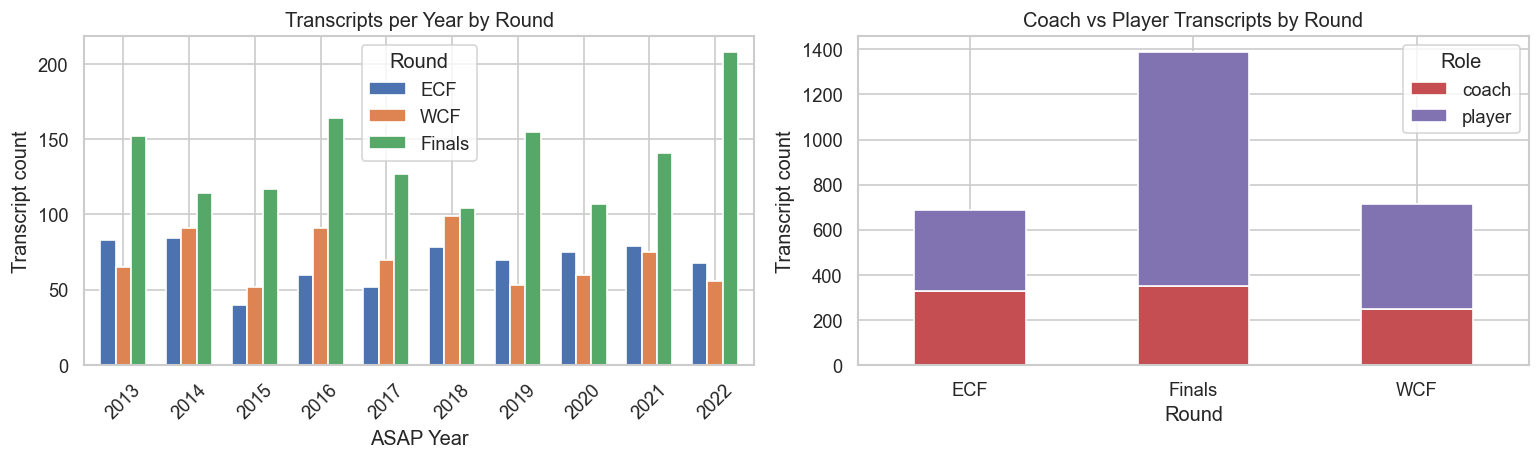

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Transcripts by year, stacked by round
by_year_round = transcripts.groupby(['asap_year', 'round']).size().unstack(fill_value=0)
by_year_round = by_year_round[['ECF', 'WCF', 'Finals']]  # consistent order
by_year_round.plot(kind='bar', stacked=False, ax=axes[0], width=0.7,
                   color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Transcripts per Year by Round')
axes[0].set_xlabel('ASAP Year')
axes[0].set_ylabel('Transcript count')
axes[0].legend(title='Round')
axes[0].tick_params(axis='x', rotation=45)

# Transcripts by round, stacked by role
by_round_role = transcripts.groupby(['round', 'role']).size().unstack(fill_value=0)
by_round_role.plot(kind='bar', stacked=True, ax=axes[1], width=0.5,
                   color=['#C44E52', '#8172B2'])
axes[1].set_title('Coach vs Player Transcripts by Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Transcript count')
axes[1].legend(title='Role')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Transcript Length Distribution

In [12]:
print('=== Word Count Stats ===')
print(transcripts['word_count'].describe().round(0).to_string())
print()
print(f'Transcripts < 100 words  : {(transcripts["word_count"] < 100).sum()} (too short for reliable sentiment)')
print(f'Transcripts 100-500 words: {((transcripts["word_count"] >= 100) & (transcripts["word_count"] < 500)).sum()}')
print(f'Transcripts > 500 words  : {(transcripts["word_count"] >= 500).sum()}')

=== Word Count Stats ===
count    2790.0
mean     1146.0
std       608.0
min        67.0
25%       718.0
50%      1059.0
75%      1471.0
max      6849.0

Transcripts < 100 words  : 2 (too short for reliable sentiment)
Transcripts 100-500 words: 311
Transcripts > 500 words  : 2477


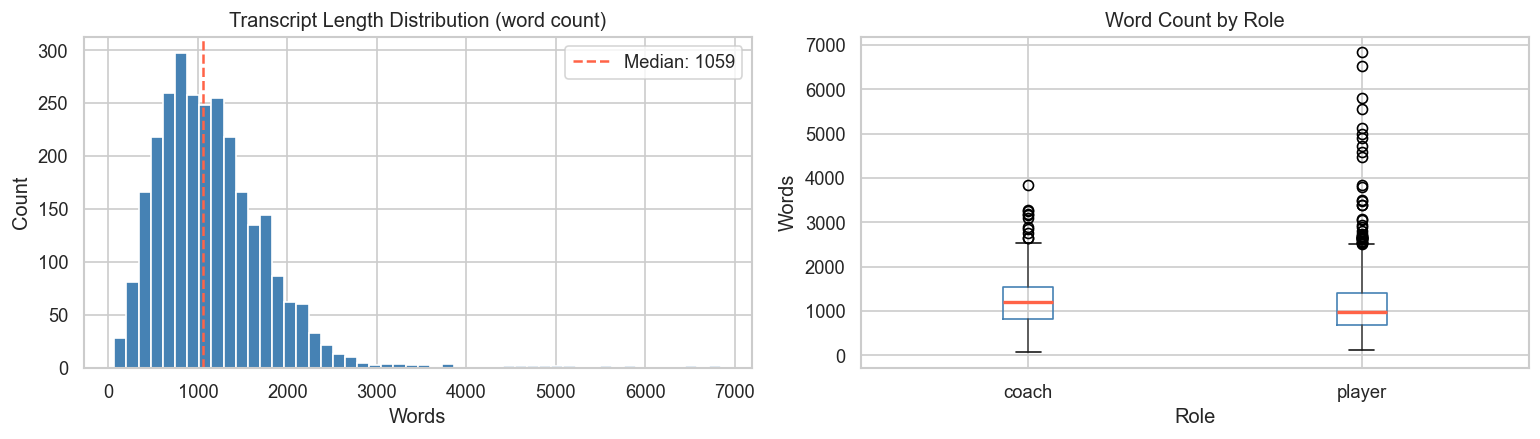

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Word count histogram
axes[0].hist(transcripts['word_count'], bins=50, edgecolor='white', color='steelblue')
axes[0].axvline(transcripts['word_count'].median(), color='tomato', linestyle='--',
                label=f'Median: {transcripts["word_count"].median():.0f}')
axes[0].set_title('Transcript Length Distribution (word count)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Count')
axes[0].legend()

# Word count by role
transcripts.boxplot(column='word_count', by='role', ax=axes[1],
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Word Count by Role')
axes[1].set_xlabel('Role')
axes[1].set_ylabel('Words')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [14]:
# Show shortest transcripts - these may be unusable for sentiment
short = transcripts[transcripts['word_count'] < 100][['speaker', 'role', 'word_count', 'event_name', 'transcript']]
short = short.sort_values('word_count')
print(f'Short transcripts (< 100 words):')
for _, row in short.head(5).iterrows():
    print(f'  [{row["word_count"]} words] {row["speaker"]} ({row["role"]})')
    print(f'  {row["transcript"][:150]}...')
    print()

Short transcripts (< 100 words):
  [67 words] ERIK SPOELSTRA (coach)
  NBA EASTERN CONFERENCE FINALS: CELTICS VS. HEAT
May 23, 2022
Erik Spoelstra
Miami Heat
Game 4: Pregame
Q.
You had a bunch of guys listed as questionab...

  [90 words] GREGG POPOVICH (coach)
  NBA FINALS: HEAT v SPURS
June 8, 2014
Gregg Popovich
SAN ANTONIO, TEXAS: Game Two
Q. Â Pop, for those of us that are not in this building more than at...



## 5. Speaker Distribution

In [15]:
print('=== Role Split ===')
print(transcripts['role'].value_counts().to_string())
print()
print('=== Top 20 Speakers ===')
print(transcripts['speaker'].value_counts().head(20).to_string())

=== Role Split ===
role
player    1863
coach      927

=== Top 20 Speakers ===
speaker
STEVE KERR          135
ERIK SPOELSTRA      120
LEBRON JAMES         96
STEPHEN CURRY        88
TYRONN LUE           87
DRAYMOND GREEN       80
KLAY THOMPSON        67
FRANK VOGEL          66
GREGG POPOVICH       66
BRAD STEVENS         52
MIKE BUDENHOLZER     52
KEVIN DURANT         47
ANDRE IGUODALA       43
COACH KERR           41
DWYANE WADE          37
NICK NURSE           37
MANU GINOBILI        36
TONY PARKER          34
MONTY WILLIAMS       33
KAWHI LEONARD        32


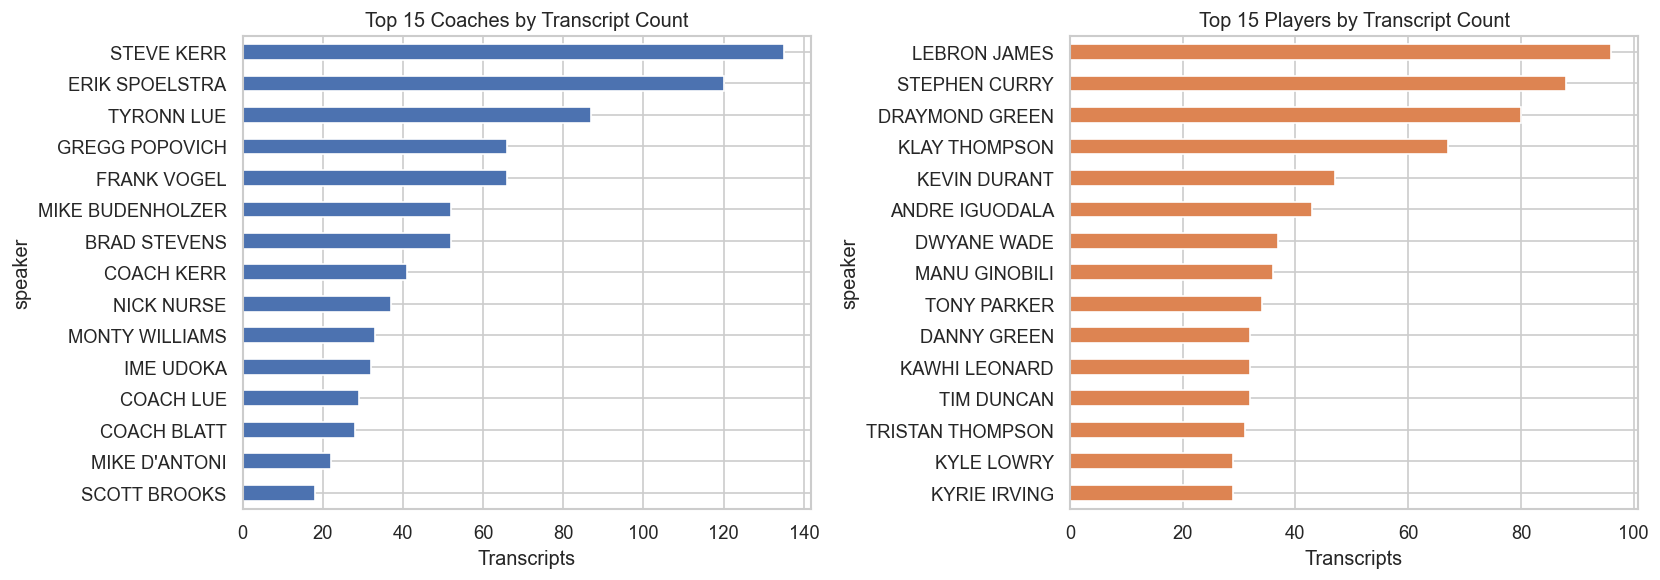

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 coaches
top_coaches = (transcripts[transcripts['role'] == 'coach']
               .groupby('speaker').size()
               .sort_values(ascending=False).head(15))
top_coaches.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Coaches by Transcript Count')
axes[0].set_xlabel('Transcripts')

# Top 15 players
top_players = (transcripts[transcripts['role'] == 'player']
               .groupby('speaker').size()
               .sort_values(ascending=False).head(15))
top_players.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Players by Transcript Count')
axes[1].set_xlabel('Transcripts')

plt.tight_layout()
plt.show()

In [17]:
# Speaker appearances by year - useful for spotting data gaps
pivot = (transcripts.groupby(['asap_year', 'role'])
         .size().unstack(fill_value=0))
pivot['total'] = pivot.sum(axis=1)
print('Transcripts by year and role:')
print(pivot.to_string())

Transcripts by year and role:
role       coach  player  total
asap_year                      
2013          91     209    300
2014         101     188    289
2015          82     127    209
2016          99     216    315
2017          83     166    249
2018         112     169    281
2019          97     181    278
2020          82     160    242
2021          98     197    295
2022          82     250    332


## 6. Date Parsing Validation

In [18]:
failed = transcripts[transcripts['date'].isna()]
print(f'Date parse failures: {len(failed)}')
if len(failed) > 0:
    print(failed[['event_date_from_page', 'speaker']].head(10).to_string())
print()

# Sanity check: transcript dates should fall in April-July (playoff season)
transcripts['month'] = transcripts['date'].dt.month
print('Transcripts by calendar month:')
print(transcripts['month'].value_counts().sort_index().to_string())
print()
print('Note: Months outside 4-7 are media/practice days or parse errors.')

Date parse failures: 150
                                                                                                                                 event_date_from_page       speaker
9    ASAP Sports Transcripts - Basketball - 2022 - NBA WESTERN CONFERENCE FINALS: MAVERICKS VS. WARRIORS - May 26 - Dorian Finney-Smith - Theo Pinson   THEO PINSON
62                 ASAP Sports Transcripts - Basketball - 2022 - NBA EASTERN CONFERENCE FINALS: CELTICS VS. HEAT - May 29 - Al Horford - Jaylen Brown  JAYLEN BROWN
63                 ASAP Sports Transcripts - Basketball - 2022 - NBA EASTERN CONFERENCE FINALS: CELTICS VS. HEAT - May 29 - Jimmy Butler - Kyle Lowry  JIMMY BUTLER
72                 ASAP Sports Transcripts - Basketball - 2022 - NBA EASTERN CONFERENCE FINALS: CELTICS VS. HEAT - May 27 - Kyle Lowry - Jimmy Butler    KYLE LOWRY
80                 ASAP Sports Transcripts - Basketball - 2022 - NBA EASTERN CONFERENCE FINALS: CELTICS VS. HEAT - May 25 - Kyle Lowry - Jimmy Butler    KY

## 7. Game Join — Proof of Concept

We need to join transcripts to Kaggle game outcomes by date + team.
This section validates how well that join works before building it properly in Phase 2.

In [19]:
# The join key is: transcript date + one of the two teams in the series.
# Extract teams from event_name: e.g. 'NBA WCF: LAKERS VS NUGGETS' -> ['LAKERS', 'NUGGETS']
# Then check if either team appears in a Kaggle game on that date.

# Build a set of (date, home_team, away_team) tuples from Kaggle
games['date'] = pd.to_datetime(games['date'])
game_dates = set(zip(
    games['date'].dt.date,
    games['home_team'],
    games['away_team']
))

# For each transcript, check if its date matches any playoff game
transcript_dates = transcripts['date'].dt.date
kaggle_date_set = set(games['date'].dt.date)

matched = transcript_dates.isin(kaggle_date_set)
print(f'Transcripts with date matching a Kaggle playoff game: {matched.sum():,} / {len(transcripts):,} ({matched.mean()*100:.1f}%)')
print()

# What dates don't match? (media/practice days between games)
no_match = transcripts[~matched]
print(f'Non-matching dates: {no_match["date"].dt.date.nunique()} unique dates')
print('Sample non-matching dates (likely media/practice days):')
print(no_match.groupby(no_match['date'].dt.date).size().head(10).to_string())

Transcripts with date matching a Kaggle playoff game: 1,638 / 2,790 (58.7%)

Non-matching dates: 81 unique dates
Sample non-matching dates (likely media/practice days):
date
2013-05-20     9
2013-05-23    24
2013-05-29     4
2013-05-31     7
2013-06-02     2
2013-06-05    12
2013-06-07    14
2013-06-08    14
2013-06-12    14
2013-06-14     2


In [20]:
# For matched transcripts, what % have both the game date AND the series year covered?
# ASAP year 2022 = Kaggle season 2021 (Finals in June 2022)
# Check coverage by year
print('Match rate by ASAP year:')
for year in sorted(transcripts['asap_year'].unique()):
    subset = transcripts[transcripts['asap_year'] == year]
    match = subset['date'].dt.date.isin(kaggle_date_set)
    print(f'  {year}: {match.sum():3d} / {len(subset):3d} matched ({match.mean()*100:.0f}%)')

Match rate by ASAP year:
  2013: 159 / 300 matched (53%)
  2014: 178 / 289 matched (62%)
  2015: 125 / 209 matched (60%)
  2016: 158 / 315 matched (50%)
  2017: 128 / 249 matched (51%)
  2018: 176 / 281 matched (63%)
  2019: 158 / 278 matched (57%)
  2020: 171 / 242 matched (71%)
  2021: 194 / 295 matched (66%)
  2022: 191 / 332 matched (58%)


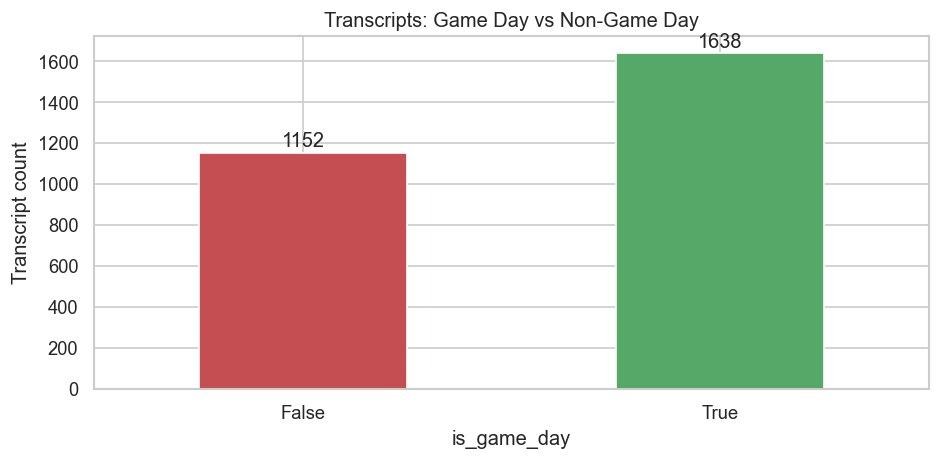

In [21]:
# Visualize: what share of each day's transcripts are game-day vs non-game-day
transcripts['is_game_day'] = transcripts['date'].dt.date.isin(kaggle_date_set)

fig, ax = plt.subplots(figsize=(8, 4))
transcripts.groupby('is_game_day').size().plot(
    kind='bar', ax=ax, color=['#C44E52', '#55A868'],
    tick_label=['Non-game day\n(media/practice)', 'Game day\n(joinable to outcome)']
)
ax.set_title('Transcripts: Game Day vs Non-Game Day')
ax.set_ylabel('Transcript count')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{bar.get_height():.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 8. Data Quality Notes

Summary of known issues to address in Phase 2 preprocessing:

In [22]:
issues = [
    ('Short transcripts (< 100 words)',
     (transcripts['word_count'] < 100).sum(),
     'Drop or exclude from sentiment scoring'),
    ('Non-game-day transcripts (media/practice days)',
     (~transcripts['is_game_day']).sum(),
     'Keep for NLP training; exclude from correlation analysis join'),
    ('Speaker name variants (COACH KERR vs STEVE KERR)',
     transcripts['speaker'].str.startswith('COACH ').sum(),
     'Add coach name mapping in preprocess.py'),
    ('Date parse failures',
     transcripts['date'].isna().sum(),
     'Investigate and fix in preprocess.py'),
]

print(f'{"Issue":<50} {"Count":>8}  Action')
print('-' * 100)
for issue, count, action in issues:
    print(f'{issue:<50} {count:>8}  {action}')

Issue                                                 Count  Action
----------------------------------------------------------------------------------------------------
Short transcripts (< 100 words)                           2  Drop or exclude from sentiment scoring
Non-game-day transcripts (media/practice days)         1152  Keep for NLP training; exclude from correlation analysis join
Speaker name variants (COACH KERR vs STEVE KERR)        136  Add coach name mapping in preprocess.py
Date parse failures                                     150  Investigate and fix in preprocess.py


In [23]:
print('=== Final Corpus Summary ===')
usable = transcripts[transcripts['word_count'] >= 100]
print(f'Total transcripts          : {len(transcripts):,}')
print(f'Usable (>= 100 words)      : {len(usable):,}')
print(f'Game-day transcripts       : {transcripts["is_game_day"].sum():,}  (joinable to outcomes)')
print(f'Non-game-day transcripts   : {(~transcripts["is_game_day"]).sum():,}  (media/practice days)')
print(f'Unique speakers            : {transcripts["speaker"].nunique()}')
print(f'ASAP years covered         : {sorted(transcripts["asap_year"].unique())}')
print(f'Avg words per transcript   : {transcripts["word_count"].mean():.0f}')
print()
print('Corpus is sufficient for fine-tuning (target: 600-800 labeled examples)')
print('and correlation analysis (game-day transcripts joinable to Kaggle outcomes).')

=== Final Corpus Summary ===
Total transcripts          : 2,790
Usable (>= 100 words)      : 2,788
Game-day transcripts       : 1,638  (joinable to outcomes)
Non-game-day transcripts   : 1,152  (media/practice days)
Unique speakers            : 250
ASAP years covered         : [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Avg words per transcript   : 1146

Corpus is sufficient for fine-tuning (target: 600-800 labeled examples)
and correlation analysis (game-day transcripts joinable to Kaggle outcomes).
